# Chronic Kidney Disease Prediction 
Dataset: UCI Chronic Kidney Disease Dataset  
Target: `classification` (ckd / notckd) → binary

## 1 · Imports & Data Load

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import joblib, json

df = pd.read_csv("../data/chronic_kidney_disease.csv")
df['target'] = (df['classification'].str.strip() == 'ckd').astype(int)
print(df.shape)
df.head()

(400, 27)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,wc,rc,htn,dm,cad,appet,pe,ane,classification,target
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,7800,5.2,yes,yes,no,good,no,no,ckd,1
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,6000,NaN,no,no,no,good,no,no,ckd,1
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,7500,NaN,no,yes,no,poor,no,yes,ckd,1
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,6700,3.9,yes,no,no,poor,yes,yes,ckd,1
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,7300,4.6,no,no,no,good,no,no,ckd,1


In [3]:
print("Target balance:", df['target'].value_counts().to_dict())
# Coerce numeric cols (dataset has mixed types / 'ckd	' artefacts)
for col in ['age','bp','sg','al','su','bu','sc']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print("\nMissing values (selected cols):")
print(df[['age','bp','sg','al','su','bu','sc']].isnull().sum())

Target balance: {1: 250, 0: 150}

Missing values (selected cols):
age     9
bp     12
sg     47
al     46
su     49
bu     19
sc     17
dtype: int64


## 2 · EDA

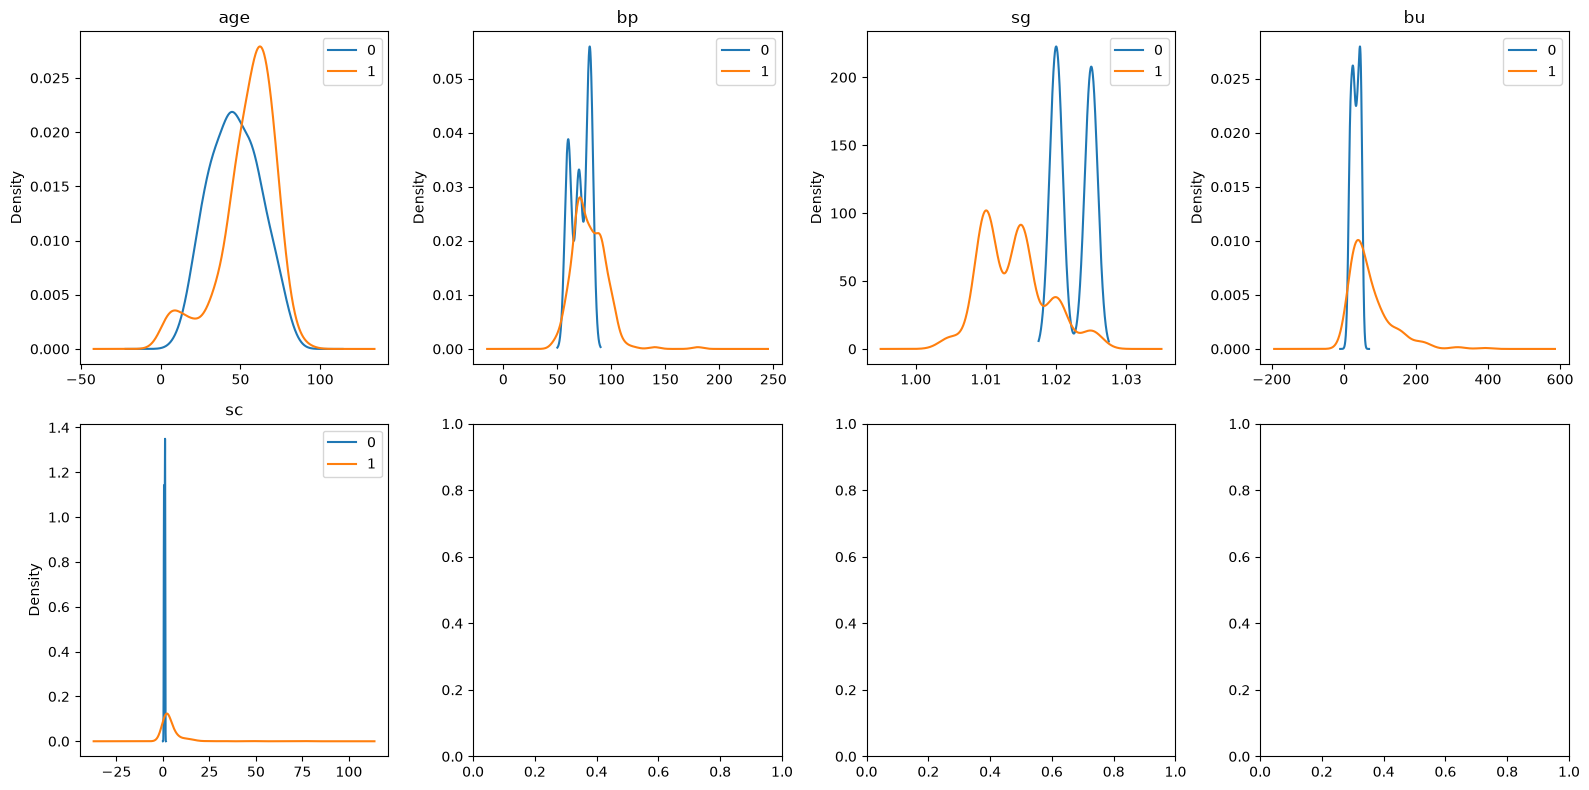

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16,8))
cols = ['age','bp','sg','bu','sc']  
for i, col in enumerate(cols):
    ax = axes[i//4][i%4]
    df.groupby('target')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
plt.tight_layout(); plt.show()

## 3 · Feature Engineering & Field Mapping


In [6]:
FEATURES = ['age','bp','sg','al','su','bu','sc']
X = df[FEATURES].rename(columns={'bu':'bhn','sc':'creatinine'})
y = df['target']
print(X.head())

    age    bp     sg   al   su   bhn  creatinine
0  48.0  80.0  1.020  1.0  0.0  36.0         1.2
1   7.0  50.0  1.020  4.0  0.0  18.0         0.8
2  62.0  80.0  1.010  2.0  3.0  53.0         1.8
3  48.0  70.0  1.005  4.0  0.0  56.0         3.8
4  51.0  80.0  1.010  2.0  0.0  26.0         1.4


## 4–5 · Preprocessing & Split

In [7]:
def make_pipe(clf):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()), ('clf', clf)])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (320, 7), Test: (80, 7)


## 6 · Model Training & Comparison

In [10]:
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':            XGBClassifier(n_estimators=200, random_state=42,
                                        eval_metric='logloss', verbosity=0),
}
results = {}; pipes = {}
for name, clf in candidates.items():
    p = make_pipe(clf); p.fit(X_train, y_train)
    yp  = p.predict(X_test)
    ypr = p.predict_proba(X_test)[:,1]
    results[name] = {'accuracy':  round(accuracy_score(y_test,yp),4),
                     'precision': round(precision_score(y_test,yp),4),
                     'recall':    round(recall_score(y_test,yp),4),
                     'f1':        round(f1_score(y_test,yp),4),
                     'roc_auc':   round(roc_auc_score(y_test,ypr),4)}
    pipes[name] = p
pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc
RandomForest,1.0000,1.0,1.00,1.0000,1.0000
XGBoost,1.0000,1.0,1.00,1.0000,1.0000
LogisticRegression,0.9875,1.0,0.98,0.9899,0.9947


## 7 · Evaluation

Best: RandomForest


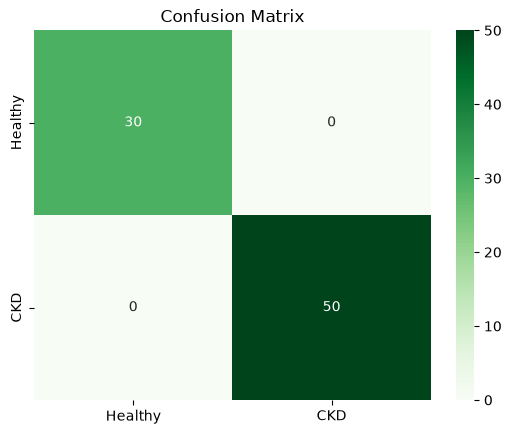

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [11]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = pipes[best_name]
print(f"Best: {best_name}")
y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:,1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy','CKD'], yticklabels=['Healthy','CKD'])
plt.title('Confusion Matrix'); plt.show()
print(classification_report(y_test, y_pred, target_names=['Healthy','CKD']))

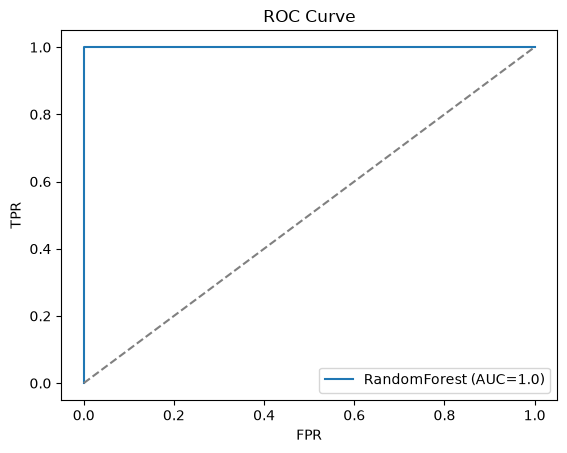

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{best_name} (AUC={results[best_name]["roc_auc"]})')
plt.plot([0,1],[0,1],'--',color='grey'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend(); plt.show()

## 8 · Save

In [14]:
joblib.dump(best, '../models/kidney_model.joblib')
metrics = {**results[best_name], 'model': best_name,
           'features': list(X.columns), 'test_size': 0.2, 'random_state': 42}
with open('../metrics/kidney_metrics.json','w') as f: json.dump(metrics,f,indent=2)